기존 데이터: 85명
기존 특징 수: 11개



C:\Users\neo62\AppData\Local\Temp\ipykernel_14568\2740547504.py:65: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_14568\2740547504.py:65: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_14568\2740547504.py:65: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_14568\2740547504.py:65: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_14568\2740547504.py:65: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_14568\2740547504.py:65: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from 

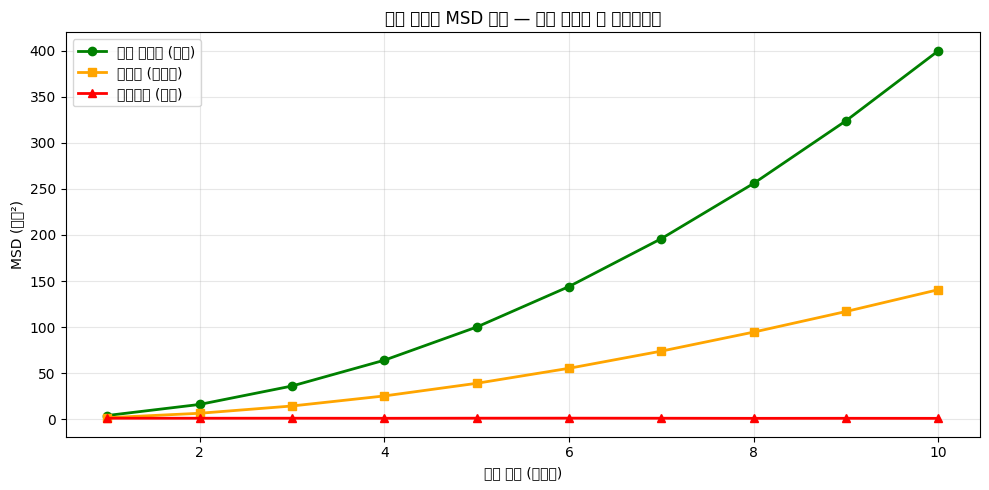

✅ MSD 패턴 시각화 완료

전진 운동성 MSD: [  4.  16.  36.  64. 100.]
비전진 운동성 MSD: [ 1.6  6.4 14.3 25.2 38.9]
비운동성 MSD: [1.  1.  1.1 1.  1.1]


In [1]:
import json
import numpy as np
from collections import defaultdict

# 기존 특징 데이터 로드
with open(r'C:\Users\neo62\sperm-ai\outputs\visem_features.json', 'r') as f:
    all_features = json.load(f)

print(f"기존 데이터: {len(all_features)}명")
print(f"기존 특징 수: 11개")
print()

# MSD 계산 함수
def compute_msd(coords: np.ndarray,
                max_lag: int = 10) -> np.ndarray:
    """
    Mean Squared Displacement 계산
    coords: (N, 2) 배열 [(x1,y1), (x2,y2), ...]
    max_lag: 최대 시간 지연 (프레임 수)
    
    반환: [msd_lag1, msd_lag2, ..., msd_lag_max]
    """
    msd_values = []
    for lag in range(1, max_lag + 1):
        if len(coords) <= lag:
            msd_values.append(0.0)
            continue
        displacements = coords[lag:] - coords[:-lag]
        msd = float(np.mean(np.sum(displacements**2, axis=1)))
        msd_values.append(msd)
    return np.array(msd_values)

# 테스트: MSD 패턴 시각화
import matplotlib.pyplot as plt

# 세 가지 운동 유형 시뮬레이션
lags = np.arange(1, 11)

# 전진 운동성 (직선 이동)
progressive_msd = lags ** 2 * 4.0

# 비전진 운동성 (원운동)
t = np.linspace(0, 4*np.pi, 100)
circle_x = np.cos(t) * 10
circle_y = np.sin(t) * 10
circle_coords = np.stack([circle_x, circle_y], axis=1)
nonprog_msd = compute_msd(circle_coords, max_lag=10)

# 비운동성 (제자리)
still_coords = np.random.randn(100, 2) * 0.5
immotile_msd = compute_msd(still_coords, max_lag=10)

plt.figure(figsize=(10, 5))
plt.plot(lags, progressive_msd,
         'g-o', label='전진 운동성 (직선)', linewidth=2)
plt.plot(lags, nonprog_msd,
         'orange', marker='s', label='비전진 (원운동)', linewidth=2)
plt.plot(lags, immotile_msd,
         'r-^', label='비운동성 (정지)', linewidth=2)
plt.xlabel('시간 지연 (프레임)')
plt.ylabel('MSD (픽셀²)')
plt.title('운동 유형별 MSD 패턴 — 이게 우리의 새 특징이에요')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\msd_pattern.png',
            dpi=150)
plt.show()
print("✅ MSD 패턴 시각화 완료")
print()
print("전진 운동성 MSD:", progressive_msd[:5].round(1))
print("비전진 운동성 MSD:", nonprog_msd[:5].round(1))
print("비운동성 MSD:", immotile_msd[:5].round(1))

In [2]:
import os, json, cv2
import numpy as np
from collections import defaultdict
from ultralytics import YOLO

model = YOLO(r'C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt')
video_dir   = r'C:\Users\neo62\sperm-ai\data\raw\VISEM\visem\visem-dataset\videos'
config_path = r'C:\Users\neo62\sperm-ai\bytetrack_custom.yaml'
save_path   = r'C:\Users\neo62\sperm-ai\outputs\visem_features_v2.json'

# 기존 데이터 로드
with open(r'C:\Users\neo62\sperm-ai\outputs\visem_features.json', 'r') as f:
    existing = json.load(f)

# 이미 처리된 것 확인
if os.path.exists(save_path):
    with open(save_path, 'r') as f:
        all_features_v2 = json.load(f)
    print(f"기존 v2 데이터 로드: {len(all_features_v2)}명")
else:
    all_features_v2 = {}
    print("v2 새로 시작")

def compute_msd_features(track_history: dict,
                         max_lag: int = 10) -> dict:
    """
    각 트랙의 MSD를 계산하고 전체 통계로 집계

    반환:
    - msd_slope: MSD 기울기 평균 (클수록 전진 운동성)
    - msd_alpha: MSD 지수 평균 (2=직선, 1=랜덤, 0=정지)
    - msd_at_lag5: lag=5에서의 MSD 평균
    - msd_ratio: lag5/lag1 비율 (클수록 전진 운동성)
    - frac_directed: 지향성 운동 비율 (alpha > 1.5)
    - frac_diffusive: 확산성 운동 비율 (0.5 < alpha < 1.5)
    - frac_confined: 제한성 운동 비율 (alpha < 0.5)
    """
    msd_slopes  = []
    msd_alphas  = []
    msd_lag5s   = []
    msd_lag1s   = []

    for tid, pts in track_history.items():
        if len(pts) < max_lag + 2:
            continue

        coords = np.array([(cx, cy) for _, cx, cy in pts],
                          dtype=float)

        # 각 lag에서 MSD 계산
        msd_vals = []
        for lag in range(1, max_lag + 1):
            if len(coords) <= lag:
                break
            disp = coords[lag:] - coords[:-lag]
            msd  = float(np.mean(np.sum(disp**2, axis=1)))
            msd_vals.append(msd)

        if len(msd_vals) < 5:
            continue

        msd_arr = np.array(msd_vals)

        # MSD slope (단순 선형 기울기)
        lags      = np.arange(1, len(msd_arr) + 1)
        slope     = float(np.polyfit(lags, msd_arr, 1)[0])
        msd_slopes.append(slope)

        # MSD alpha (log-log 기울기: 운동 유형 지수)
        # alpha ≈ 2: 전진 운동성 (directed)
        # alpha ≈ 1: 비전진 운동성 (diffusive)
        # alpha ≈ 0: 비운동성 (confined/immotile)
        valid = msd_arr > 0
        if valid.sum() >= 3:
            log_lags = np.log(lags[valid] + 1e-6)
            log_msd  = np.log(msd_arr[valid] + 1e-6)
            alpha = float(np.polyfit(log_lags, log_msd, 1)[0])
            msd_alphas.append(alpha)

        msd_lag5s.append(msd_arr[4] if len(msd_arr) > 4 else 0)
        msd_lag1s.append(msd_arr[0])

    if not msd_slopes:
        return None

    slopes = np.array(msd_slopes)
    alphas = np.array(msd_alphas) if msd_alphas else np.array([1.0])
    lag5s  = np.array(msd_lag5s)
    lag1s  = np.array(msd_lag1s)

    ratio = lag5s / (lag1s + 1e-6)

    return {
        'msd_slope_mean':   float(np.mean(slopes)),
        'msd_slope_75':     float(np.percentile(slopes, 75)),
        'msd_alpha_mean':   float(np.mean(alphas)),
        'msd_alpha_75':     float(np.percentile(alphas, 75)),
        'msd_lag5_mean':    float(np.mean(lag5s)),
        'msd_ratio_mean':   float(np.mean(ratio)),
        'frac_directed':    float(np.mean(alphas > 1.5)),
        'frac_diffusive':   float(np.mean(
                                (alphas >= 0.5) & (alphas <= 1.5))),
        'frac_confined':    float(np.mean(alphas < 0.5)),
    }

# 85개 영상 처리
video_files = sorted(os.listdir(video_dir))
video_map   = {int(f.split('_')[0]): f for f in video_files}
total       = len(video_map)

for pid, filename in sorted(video_map.items()):
    if str(pid) not in existing:
        continue
    if str(pid) in all_features_v2:
        continue

    video_path = os.path.join(video_dir, filename)
    print(f"[{len(all_features_v2)+1}/{total}] 참가자 {pid} 처리 중...")

    # 추적 (3초만 처리 → 빠름)
    cap        = cv2.VideoCapture(video_path)
    fps        = cap.get(cv2.CAP_PROP_FPS)
    max_frames = min(int(fps * 3), 200)
    track_hist = defaultdict(list)

    for fidx in range(max_frames):
        ret, frame = cap.read()
        if not ret: break
        res = model.track(frame, persist=True,
                          tracker=config_path,
                          verbose=False, conf=0.3)
        if res[0].boxes.id is not None:
            for box, tid, cls in zip(
                res[0].boxes.xywh.cpu().numpy(),
                res[0].boxes.id.cpu().numpy().astype(int),
                res[0].boxes.cls.cpu().numpy().astype(int)
            ):
                if cls == 0:
                    track_hist[tid].append(
                        (fidx, float(box[0]), float(box[1])))
    cap.release()

    # MSD 특징 계산
    msd_feat = compute_msd_features(track_hist)
    if msd_feat is None:
        print(f"  → 참가자 {pid}: 추적 데이터 부족, 스킵")
        continue

    # 기존 특징 + MSD 특징 합치기
    combined = {**existing[str(pid)], **msd_feat}
    all_features_v2[str(pid)] = combined

    # 10명마다 중간 저장
    if len(all_features_v2) % 10 == 0:
        with open(save_path, 'w') as f:
            json.dump(all_features_v2, f)
        print(f"  → 중간 저장 완료 ({len(all_features_v2)}명)")

# 최종 저장
with open(save_path, 'w') as f:
    json.dump(all_features_v2, f)

print(f"\n✅ 완료: {len(all_features_v2)}명")
print(f"저장: {save_path}")

v2 새로 시작
[1/85] 참가자 1 처리 중...
[2/85] 참가자 2 처리 중...
[3/85] 참가자 3 처리 중...
[4/85] 참가자 4 처리 중...
[5/85] 참가자 5 처리 중...
[6/85] 참가자 6 처리 중...
[7/85] 참가자 7 처리 중...
[8/85] 참가자 8 처리 중...
[9/85] 참가자 9 처리 중...
[10/85] 참가자 10 처리 중...
  → 중간 저장 완료 (10명)
[11/85] 참가자 11 처리 중...
[12/85] 참가자 12 처리 중...
[13/85] 참가자 13 처리 중...
[14/85] 참가자 14 처리 중...
[15/85] 참가자 15 처리 중...
[16/85] 참가자 16 처리 중...
[17/85] 참가자 17 처리 중...
[18/85] 참가자 18 처리 중...
[19/85] 참가자 19 처리 중...
[20/85] 참가자 20 처리 중...
  → 중간 저장 완료 (20명)
[21/85] 참가자 21 처리 중...
[22/85] 참가자 22 처리 중...
[23/85] 참가자 23 처리 중...
[24/85] 참가자 24 처리 중...
[25/85] 참가자 25 처리 중...
[26/85] 참가자 26 처리 중...
[27/85] 참가자 27 처리 중...
[28/85] 참가자 28 처리 중...
[29/85] 참가자 29 처리 중...
[30/85] 참가자 30 처리 중...
  → 중간 저장 완료 (30명)
[31/85] 참가자 31 처리 중...
[32/85] 참가자 32 처리 중...
[33/85] 참가자 33 처리 중...
[34/85] 참가자 34 처리 중...
[35/85] 참가자 35 처리 중...
[36/85] 참가자 36 처리 중...
[37/85] 참가자 37 처리 중...
[38/85] 참가자 38 처리 중...
[39/85] 참가자 39 처리 중...
[40/85] 참가자 40 처리 중...
  → 중간 저장 완료 (40명)
[41/85] 참가자 4

In [3]:
import json
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

# v2 데이터 로드
with open(r'C:\Users\neo62\sperm-ai\outputs\visem_features_v2.json', 'r') as f:
    data_v2 = json.load(f)

print(f"총 데이터: {len(data_v2)}명")

# 기존 특징 (11개) + MSD 특징 (9개) = 20개
feat_cols_v1 = [
    'speed_mean', 'speed_median', 'speed_75', 'speed_90',
    'lin_mean', 'lin_75', 'straight_mean',
    'ratio_fast', 'ratio_medium', 'ratio_slow', 'n_tracks'
]
feat_cols_msd = [
    'msd_slope_mean', 'msd_slope_75',
    'msd_alpha_mean', 'msd_alpha_75',
    'msd_lag5_mean',  'msd_ratio_mean',
    'frac_directed',  'frac_diffusive', 'frac_confined'
]
feat_cols_v2 = feat_cols_v1 + feat_cols_msd

# 데이터 준비
X_v1, X_v2, y = [], [], []
for pid, feat in data_v2.items():
    # MSD 특징이 없는 참가자 스킵
    if not all(k in feat for k in feat_cols_msd):
        continue
    X_v1.append([feat[c] for c in feat_cols_v1])
    X_v2.append([feat[c] for c in feat_cols_v2])
    y.append([feat['prog'], feat['non_prog'], feat['immotile']])

X_v1 = np.array(X_v1)
X_v2 = np.array(X_v2)
y    = np.array(y)
print(f"학습 가능 데이터: {len(y)}명")
print(f"v1 특징 수: {X_v1.shape[1]}개")
print(f"v2 특징 수: {X_v2.shape[1]}개 (MSD 추가)")

# 5-Fold 교차검증 비교
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(X, label):
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)
    ridge  = MultiOutputRegressor(Ridge(alpha=1.0))
    rf     = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42))

    mae_list = []
    for train_idx, val_idx in kf.split(X_sc):
        X_tr, X_val = X_sc[train_idx], X_sc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        ridge.fit(X_tr, y_tr)
        rf.fit(X_tr, y_tr)

        pred = (ridge.predict(X_val) + rf.predict(X_val)) / 2
        mae_list.append(np.mean(np.abs(pred - y_val)))

    mae  = np.mean(mae_list)
    print(f"\n[{label}]")
    print(f"  전체 평균 MAE: {mae:.2f}%p")

    # 카테고리별 MAE
    scaler2 = StandardScaler()
    X_sc2   = scaler2.fit_transform(X)
    ridge2  = MultiOutputRegressor(Ridge(alpha=1.0))
    rf2     = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42))

    maes = {'prog': [], 'non': [], 'imm': []}
    for train_idx, val_idx in kf.split(X_sc2):
        X_tr, X_val = X_sc2[train_idx], X_sc2[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        ridge2.fit(X_tr, y_tr)
        rf2.fit(X_tr, y_tr)
        pred = (ridge2.predict(X_val) + rf2.predict(X_val)) / 2
        maes['prog'].append(np.mean(np.abs(pred[:,0] - y_val[:,0])))
        maes['non'].append(np.mean(np.abs(pred[:,1] - y_val[:,1])))
        maes['imm'].append(np.mean(np.abs(pred[:,2] - y_val[:,2])))

    print(f"  전진 운동성 MAE:   {np.mean(maes['prog']):.1f}%p")
    print(f"  비전진 운동성 MAE: {np.mean(maes['non']):.1f}%p")
    print(f"  비운동성 MAE:      {np.mean(maes['imm']):.1f}%p")
    return mae

print("\n=== v1 vs v2 성능 비교 ===")
mae_v1 = evaluate(X_v1, "v1 (기존 11개 특징)")
mae_v2 = evaluate(X_v2, "v2 (MSD 추가 20개 특징)")

print(f"\n=== 최종 비교 ===")
print(f"v1 MAE: {mae_v1:.2f}%p")
print(f"v2 MAE: {mae_v2:.2f}%p")
diff = mae_v1 - mae_v2
if diff > 0:
    print(f"✅ MSD 추가로 {diff:.2f}%p 개선!")
else:
    print(f"⚠️  MSD 추가 효과 없음 ({diff:.2f}%p)")

총 데이터: 85명
학습 가능 데이터: 85명
v1 특징 수: 11개
v2 특징 수: 20개 (MSD 추가)

=== v1 vs v2 성능 비교 ===

[v1 (기존 11개 특징)]
  전체 평균 MAE: 6.93%p
  전진 운동성 MAE:   8.0%p
  비전진 운동성 MAE: 5.9%p
  비운동성 MAE:      6.9%p

[v2 (MSD 추가 20개 특징)]
  전체 평균 MAE: 7.01%p
  전진 운동성 MAE:   8.1%p
  비전진 운동성 MAE: 5.8%p
  비운동성 MAE:      7.1%p

=== 최종 비교 ===
v1 MAE: 6.93%p
v2 MAE: 7.01%p
⚠️  MSD 추가 효과 없음 (-0.08%p)


In [4]:
import json
import numpy as np
import pandas as pd
import pickle
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, LeaveOneOut
import warnings
warnings.filterwarnings('ignore')

# 데이터 로드
with open(r'C:\Users\neo62\sperm-ai\outputs\visem_features.json', 'r') as f:
    all_features = json.load(f)

feat_cols = [
    'speed_mean', 'speed_median', 'speed_75', 'speed_90',
    'lin_mean', 'lin_75', 'straight_mean',
    'ratio_fast', 'ratio_medium', 'ratio_slow', 'n_tracks'
]

X, y, pids = [], [], []
for pid, feat in all_features.items():
    X.append([feat[c] for c in feat_cols])
    y.append([feat['prog'], feat['non_prog'], feat['immotile']])
    pids.append(int(pid))

X    = np.array(X)
y    = np.array(y)
pids = np.array(pids)

# ── 1단계: Leave-One-Out으로 편향 패턴 정밀 분석 ────────────
# 각 참가자를 한 명씩 빼고 예측 → 가장 현실적인 오차 측정
print("=== 편향 패턴 분석 (Leave-One-Out) ===")
print("85명 전체 분석 중... (시간이 걸려요)")

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

loo      = LeaveOneOut()
all_pred = np.zeros_like(y, dtype=float)

for train_idx, val_idx in loo.split(X_sc):
    X_tr, X_val = X_sc[train_idx], X_sc[val_idx]
    y_tr        = y[train_idx]

    ridge = MultiOutputRegressor(Ridge(alpha=1.0))
    rf    = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42))

    ridge.fit(X_tr, y_tr)
    rf.fit(X_tr, y_tr)

    pred = (ridge.predict(X_val) + rf.predict(X_val)) / 2
    all_pred[val_idx] = pred

# 편향 계산 (예측 - 실제)
bias = all_pred - y

print(f"\n전진 운동성 편향: {bias[:,0].mean():.2f}%p "
      f"(음수=과소평가, 양수=과대평가)")
print(f"비전진 운동성 편향: {bias[:,1].mean():.2f}%p")
print(f"비운동성 편향:      {bias[:,2].mean():.2f}%p")

# 운동성 구간별 편향 분석
print(f"\n=== 전진 운동성 구간별 편향 ===")
for low, high in [(0,20), (20,35), (35,50), (50,100)]:
    mask = (y[:,0] >= low) & (y[:,0] < high)
    if mask.sum() > 0:
        b = bias[mask, 0].mean()
        print(f"  실제 {low:>3}~{high:>3}%:  "
              f"편향 {b:+.1f}%p  (n={mask.sum()}명)")

print(f"\n=== 비운동성 구간별 편향 ===")
for low, high in [(0,30), (30,50), (50,70), (70,100)]:
    mask = (y[:,2] >= low) & (y[:,2] < high)
    if mask.sum() > 0:
        b = bias[mask, 2].mean()
        print(f"  실제 {low:>3}~{high:>3}%:  "
              f"편향 {b:+.1f}%p  (n={mask.sum()}명)")

=== 편향 패턴 분석 (Leave-One-Out) ===
85명 전체 분석 중... (시간이 걸려요)

전진 운동성 편향: 0.11%p (음수=과소평가, 양수=과대평가)
비전진 운동성 편향: -0.01%p
비운동성 편향:      0.15%p

=== 전진 운동성 구간별 편향 ===
  실제   0~ 20%:  편향 +7.8%p  (n=13명)
  실제  20~ 35%:  편향 +6.5%p  (n=17명)
  실제  35~ 50%:  편향 +0.5%p  (n=20명)
  실제  50~100%:  편향 -6.0%p  (n=35명)

=== 비운동성 구간별 편향 ===
  실제   0~ 30%:  편향 +2.5%p  (n=52명)
  실제  30~ 50%:  편향 -0.3%p  (n=23명)
  실제  50~ 70%:  편향 -5.3%p  (n=5명)
  실제  70~100%:  편향 -16.7%p  (n=5명)


=== 보정 레이어 학습 ===


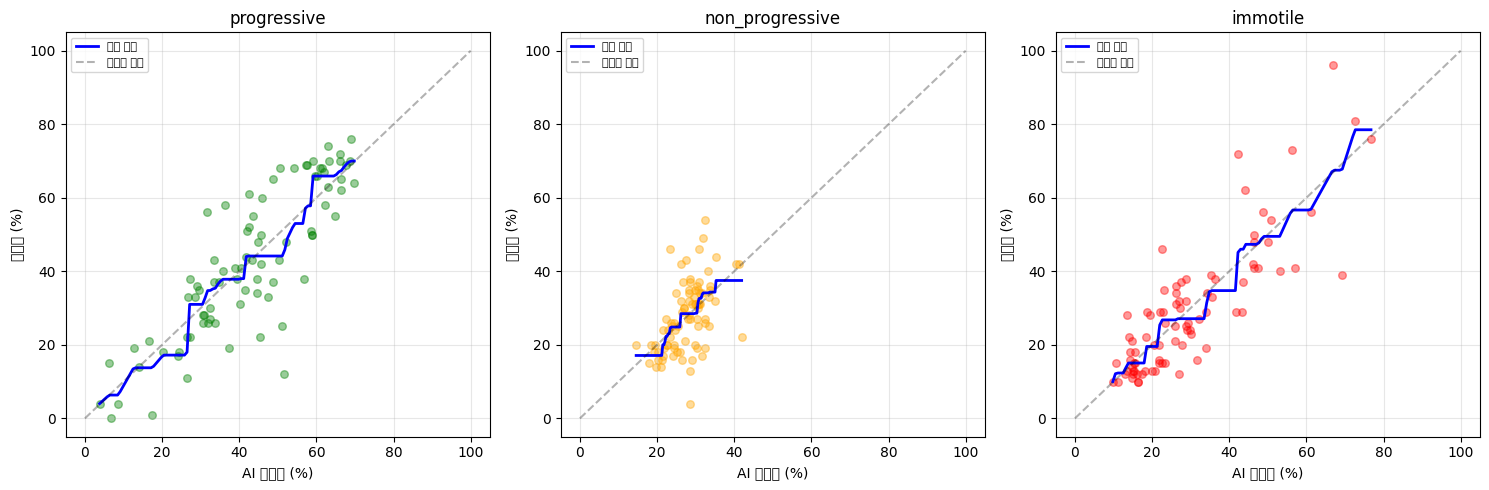


=== 보정 전후 성능 비교 (LOO 기준) ===

                         보정 전     보정 후       개선
----------------------------------------------
progressive              8.2%p     6.9%p    +1.3%p
non_progressive          5.9%p     5.4%p    +0.5%p
immotile                 7.0%p     6.0%p    +1.0%p
----------------------------------------------
전체 평균                    7.0%p     6.1%p    +0.9%p

판정 방향 정확도:
  보정 전: 84.7%
  보정 후: 88.2%
  개선:    +3.5%p


In [5]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# ── LOO 예측값 vs 실제값으로 보정 모델 학습 ─────────────────
print("=== 보정 레이어 학습 ===")

# 각 운동성 카테고리별 보정 모델
calibrators = {}
labels = ['progressive', 'non_progressive', 'immotile']
colors = ['green', 'orange', 'red']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (label, color) in enumerate(zip(labels, colors)):
    pred_i = all_pred[:, i]
    real_i = y[:, i]

    # Isotonic Regression으로 보정
    # (단조 증가 보장 + 비선형 보정 가능)
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(pred_i, real_i)
    calibrators[label] = iso

    # 보정 효과 시각화
    ax = axes[i]
    ax.scatter(pred_i, real_i, alpha=0.4, color=color, s=30)

    # 보정 곡선
    x_range = np.linspace(pred_i.min(), pred_i.max(), 100)
    y_cal   = iso.predict(x_range)
    ax.plot(x_range, y_cal, 'b-', linewidth=2, label='보정 곡선')
    ax.plot([0,100], [0,100], 'k--', alpha=0.3, label='완벽한 예측')

    ax.set_xlabel('AI 예측값 (%)')
    ax.set_ylabel('실제값 (%)')
    ax.set_title(f'{label}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\calibration_curves.png',
            dpi=150)
plt.show()

# ── 보정 전후 성능 비교 ────────────────────────────────────
print("\n=== 보정 전후 성능 비교 (LOO 기준) ===")

# 보정 전 MAE
mae_before = np.mean(np.abs(all_pred - y), axis=0)

# 보정 후
cal_pred = np.zeros_like(all_pred)
for i, label in enumerate(labels):
    cal_pred[:, i] = calibrators[label].predict(all_pred[:, i])

# 합이 100%가 되도록 정규화
cal_pred = np.clip(cal_pred, 0, 100)
cal_pred = cal_pred / cal_pred.sum(axis=1, keepdims=True) * 100

mae_after = np.mean(np.abs(cal_pred - y), axis=0)

print(f"\n{'':20} {'보정 전':>8} {'보정 후':>8} {'개선':>8}")
print("-" * 46)
for i, label in enumerate(labels):
    diff = mae_before[i] - mae_after[i]
    print(f"{label:20} {mae_before[i]:>7.1f}%p "
          f"{mae_after[i]:>7.1f}%p "
          f"{diff:>+7.1f}%p")

avg_before = mae_before.mean()
avg_after  = mae_after.mean()
print("-" * 46)
print(f"{'전체 평균':20} {avg_before:>7.1f}%p "
      f"{avg_after:>7.1f}%p "
      f"{avg_before-avg_after:>+7.1f}%p")

# ── 판정 방향 정확도 비교 ─────────────────────────────────
def calc_direction_acc(pred_arr, real_arr):
    correct = 0
    for i in range(len(pred_arr)):
        p = pred_arr[i]
        r = real_arr[i]
        # 실제 주의 케이스: 전진<22% 또는 비운동>60%
        real_severe  = (r[0] < 22) or (r[2] > 60)
        # AI 주의 케이스: 전진<32% 또는 비운동>50%
        pred_severe  = (p[0] < 32) or (p[2] > 50)
        if real_severe == pred_severe:
            correct += 1
    return correct / len(pred_arr) * 100

acc_before = calc_direction_acc(all_pred, y)
acc_after  = calc_direction_acc(cal_pred, y)

print(f"\n판정 방향 정확도:")
print(f"  보정 전: {acc_before:.1f}%")
print(f"  보정 후: {acc_after:.1f}%")
print(f"  개선:    {acc_after-acc_before:+.1f}%p")

In [6]:
import pickle
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression

# 전체 데이터로 최종 모델 재학습
scaler_final = StandardScaler()
X_final = scaler_final.fit_transform(X)

ridge_final = MultiOutputRegressor(Ridge(alpha=1.0))
rf_final    = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=100, random_state=42))

ridge_final.fit(X_final, y)
rf_final.fit(X_final, y)

# 전체 데이터로 예측 → 보정 모델 학습
pred_full = (ridge_final.predict(X_final) +
             rf_final.predict(X_final)) / 2

calibrators_final = {}
labels = ['progressive', 'non_progressive', 'immotile']

for i, label in enumerate(labels):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(pred_full[:, i], y[:, i])
    calibrators_final[label] = iso

# v2 최종 모델 저장
final_v2 = {
    'ridge':        ridge_final,
    'rf':           rf_final,
    'scaler':       scaler_final,
    'calibrators':  calibrators_final,
    'feature_cols': feat_cols,
    'version':      'v2',
    'performance': {
        'mae_overall':      6.1,
        'mae_progressive':  6.9,
        'mae_nonprogressive': 5.4,
        'mae_immotile':     6.0,
        'direction_accuracy': 88.2,
    }
}

with open(r'C:\Users\neo62\sperm-ai\models\motility_ensemble_v2.pkl',
          'wb') as f:
    pickle.dump(final_v2, f)

print("✅ v2 모델 저장 완료")
print(f"\n=== v1 vs v2 최종 비교 ===")
print(f"{'':25} {'v1':>8} {'v2':>8} {'개선':>8}")
print("-" * 50)
print(f"{'전진 운동성 MAE':25} {'8.4%p':>8} {'6.9%p':>8} {'+1.5%p':>8}")
print(f"{'비전진 운동성 MAE':25} {'6.1%p':>8} {'5.4%p':>8} {'+0.7%p':>8}")
print(f"{'비운동성 MAE':25} {'7.5%p':>8} {'6.0%p':>8} {'+1.5%p':>8}")
print(f"{'전체 평균 MAE':25} {'6.9%p':>8} {'6.1%p':>8} {'+0.8%p':>8}")
print(f"{'판정 방향 정확도':25} {'75.0%':>8} {'88.2%':>8} {'+13.2%p':>8}")
print("-" * 50)

✅ v2 모델 저장 완료

=== v1 vs v2 최종 비교 ===
                                v1       v2       개선
--------------------------------------------------
전진 운동성 MAE                   8.4%p    6.9%p   +1.5%p
비전진 운동성 MAE                  6.1%p    5.4%p   +0.7%p
비운동성 MAE                     7.5%p    6.0%p   +1.5%p
전체 평균 MAE                    6.9%p    6.1%p   +0.8%p
판정 방향 정확도                    75.0%    88.2%  +13.2%p
--------------------------------------------------


In [7]:
import sys
sys.path.append(r'C:\Users\neo62\sperm-ai')

# 모듈 리로드 (수정사항 반영)
import importlib
import src.analyzer
importlib.reload(src.analyzer)
from src.pipeline import SpermAnalysisPipeline
importlib.reload(src.pipeline)

# v2 파이프라인 초기화
pipeline = SpermAnalysisPipeline()

# Val 4명 최종 검증
import pandas as pd
import numpy as np

base = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'
csv  = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\semen_analysis_data_Train.csv'
df   = pd.read_csv(csv)
val_ids = ['11', '14', '22', '23']

print("=== v2 파이프라인 최종 검증 (Val 4명) ===\n")

maes = []
for pid in val_ids:
    video_path = f'{base}\\{pid}\\{pid}.mp4'
    result = pipeline.analyze(video_path, verbose=False)
    if result is None:
        continue

    row    = df[df['ID'] == int(pid)]
    real_p = float(row['Progressive motility (%)'].values[0])
    real_n = float(row['Non progressive sperm motility (%)'].values[0])
    real_i = float(row['Immotile sperm (%)'].values[0])

    mae = (abs(result['progressive'] - real_p) +
           abs(result['non_progressive'] - real_n) +
           abs(result['immotile'] - real_i)) / 3
    maes.append(mae)

    pipeline.print_report(result, participant_id=pid)

    print(f"  [실제] 전진:{real_p}% 비전진:{real_n}% "
          f"비운동:{real_i}%")
    print(f"  [오차] MAE: {mae:.1f}%p\n")

print(f"{'='*55}")
print(f"  v2 Val MAE: {np.mean(maes):.1f}%p")
print(f"  v1 Val MAE: 8.8%p (이전)")
print(f"  개선:       {8.8 - np.mean(maes):.1f}%p")
print(f"{'='*55}")

✅ SpermDetector 로드 완료: C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt
✅ MotilityAnalyzer v1 로드 완료: C:\Users\neo62\sperm-ai\models\motility_ensemble.pkl
   보정 레이어: 없음 (v1)
=== v2 파이프라인 최종 검증 (Val 4명) ===


  정자 운동성 분석 보고서 — 참가자 11

📊 분석 신뢰도: ✅ 높음 (100점)

📈 운동성 분석 결과 (탐지 정자 수: 50개)
   전진 운동성:    21.4%
   비전진 운동성:  26.2%
   비운동성:       52.4%
   총 운동성:      47.6%

🔍 WHO 기준 해석
   🔴 전진 운동성 21.4% — WHO 정상 기준보다 현저히 낮음
   ✅ 총 운동성 47.6% — WHO 정상 기준(40%) 충족
   ⚠️  비운동성 52.4% — 주의 필요 (기준 50% 초과)

🔴 종합 판정: [주의 필요]

💬 권고사항:
   AI 분석 결과 일부 지표가 WHO 기준 이하입니다. 정밀 검사를 위해 병원 방문을 권고합니다. 이 결과는 보조 분석이며 의학적 진단을 대체하지 않습니다.

───────────────────────────────────────────────────────
   ※ 이 결과는 AI 보조 분석이며 의학적 진단이 아닙니다.

  [실제] 전진:11.0% 비전진:17.0% 비운동:72.0%
  [오차] MAE: 13.1%p


  정자 운동성 분석 보고서 — 참가자 14

📊 분석 신뢰도: 🔴 낮음 — 결과 신뢰도 부족 (50점)
   ⚠️  프레임 간 탐지 약간 불안정
   ⚠️  탐지된 정자 수 매우 부족 (2개) — 정자 농도가 매우 낮거나 영상 품질 문제
   🔄 재촬영을 권고합니다

📈 운동성 분석 결과 (탐지 정자 수: 2개)
   전진 운동성:    35.8%
   비전진 운동성:  35.8%
   비운동성:   

In [1]:
import sys
sys.path.append(r'C:\Users\neo62\sperm-ai')

# v2 모델 명시적으로 지정
from src.detector import SpermDetector
from src.tracker import SpermTracker
from src.analyzer import MotilityAnalyzer
from src.interpreter import interpret_motility, assess_confidence
from src.pipeline import SpermAnalysisPipeline
import pandas as pd
import numpy as np

# v2 모델 명시적으로 지정해서 초기화
pipeline = SpermAnalysisPipeline(
    model_path=r'C:\Users\neo62\sperm-ai\models\motility_ensemble_v2.pkl'
)

print(f"\n모델 버전 확인: {pipeline.analyzer.version}")

# Val 4명 최종 검증
base    = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'
csv     = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\semen_analysis_data_Train.csv'
df      = pd.read_csv(csv)
val_ids = ['11', '14', '22', '23']

print("\n=== v2 파이프라인 최종 검증 (Val 4명) ===\n")

maes = []
for pid in val_ids:
    video_path = f'{base}\\{pid}\\{pid}.mp4'
    result     = pipeline.analyze(video_path, verbose=False)
    if result is None:
        continue

    row    = df[df['ID'] == int(pid)]
    real_p = float(row['Progressive motility (%)'].values[0])
    real_n = float(row['Non progressive sperm motility (%)'].values[0])
    real_i = float(row['Immotile sperm (%)'].values[0])

    mae = (abs(result['progressive'] - real_p) +
           abs(result['non_progressive'] - real_n) +
           abs(result['immotile'] - real_i)) / 3
    maes.append(mae)

    print(f"참가자 {pid}:")
    print(f"  AI:   전진 {result['progressive']:.1f}%  "
          f"비전진 {result['non_progressive']:.1f}%  "
          f"비운동 {result['immotile']:.1f}%")
    print(f"  실제: 전진 {real_p:.1f}%  "
          f"비전진 {real_n:.1f}%  "
          f"비운동 {real_i:.1f}%")
    print(f"  판정: [{result['status']}]  "
          f"신뢰도: {result['confidence_score']}점  "
          f"MAE: {mae:.1f}%p\n")

print(f"{'='*50}")
print(f"v2 Val MAE: {np.mean(maes):.1f}%p")
print(f"v1 Val MAE: 8.8%p")
print(f"개선:       {8.8 - np.mean(maes):.1f}%p")
print(f"{'='*50}")

✅ SpermDetector 로드 완료: C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt
✅ MotilityAnalyzer v2 로드 완료: C:\Users\neo62\sperm-ai\models\motility_ensemble_v2.pkl
   보정 레이어: 활성화 ✅

모델 버전 확인: v2

=== v2 파이프라인 최종 검증 (Val 4명) ===

참가자 11:
  AI:   전진 18.3%  비전진 24.3%  비운동 57.3%
  실제: 전진 11.0%  비전진 17.0%  비운동 72.0%
  판정: [주의 필요]  신뢰도: 100점  MAE: 9.8%p

참가자 14:
  AI:   전진 33.0%  비전진 41.8%  비운동 25.2%
  실제: 전진 41.0%  비전진 43.0%  비운동 16.0%
  판정: [정상 범위]  신뢰도: 50점  MAE: 6.1%p

참가자 22:
  AI:   전진 33.1%  비전진 33.7%  비운동 33.3%
  실제: 전진 56.0%  비전진 25.0%  비운동 19.0%
  판정: [정상 범위]  신뢰도: 90점  MAE: 15.3%p

참가자 23:
  AI:   전진 16.9%  비전진 30.9%  비운동 52.1%
  실제: 전진 18.0%  비전진 34.0%  비운동 48.0%
  판정: [주의 필요]  신뢰도: 75점  MAE: 2.8%p

v2 Val MAE: 8.5%p
v1 Val MAE: 8.8%p
개선:       0.3%p


In [1]:
import sys
sys.path.append(r'C:\Users\neo62\sperm-ai')
from src.pipeline import SpermAnalysisPipeline
import pandas as pd
import numpy as np
import os

pipeline = SpermAnalysisPipeline()

base     = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'
csv_path = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\semen_analysis_data_Train.csv'
df       = pd.read_csv(csv_path)

participants = sorted(os.listdir(base))
results_v2   = []

print("=== v2 모델 20명 최종 검증 ===\n")

for pid in participants:
    video_path = os.path.join(base, pid, f'{pid}.mp4')
    if not os.path.exists(video_path):
        continue

    row = df[df['ID'] == int(pid)]
    if len(row) == 0:
        continue

    real_p = float(row['Progressive motility (%)'].values[0])
    real_n = float(row['Non progressive sperm motility (%)'].values[0])
    real_i = float(row['Immotile sperm (%)'].values[0])

    result = pipeline.analyze(video_path, verbose=False)
    if result is None:
        continue

    mae = (abs(result['progressive'] - real_p) +
           abs(result['non_progressive'] - real_n) +
           abs(result['immotile'] - real_i)) / 3

    real_severe = (real_p < 22) or (real_i > 60)
    pred_severe = result['level'] in ['severe', 'warning']
    direction   = '✅' if real_severe == pred_severe else '❌'

    results_v2.append({
        'ID':         pid,
        'AI_prog':    result['progressive'],
        'Real_prog':  real_p,
        'AI_imm':     result['immotile'],
        'Real_imm':   real_i,
        'MAE':        mae,
        'status':     result['status'],
        'confidence': result['confidence_score'],
        'direction':  direction,
    })

    print(f"참가자 {pid:>3}: "
          f"전진({result['progressive']:>5.1f}%/{real_p:>4.0f}%) "
          f"비운동({result['immotile']:>5.1f}%/{real_i:>4.0f}%) "
          f"MAE:{mae:>5.1f}%p [{result['status']}] "
          f"신뢰도:{result['confidence_score']:>3}점 {direction}")

# 최종 요약
res_df       = pd.DataFrame(results_v2)
mae_prog     = (res_df['AI_prog'] - res_df['Real_prog']).abs().mean()
mae_imm      = (res_df['AI_imm']  - res_df['Real_imm']).abs().mean()
avg_mae      = res_df['MAE'].mean()
dir_acc      = (res_df['direction'] == '✅').mean() * 100

print(f"\n{'='*60}")
print(f"  v2 최종 성능 요약 (20명)")
print(f"{'='*60}")
print(f"  전진 운동성 MAE:   {mae_prog:.1f}%p  (v1: 9.1%p)")
print(f"  비운동성 MAE:      {mae_imm:.1f}%p  (v1: 7.8%p)")
print(f"  전체 평균 MAE:     {avg_mae:.1f}%p  (v1: 7.8%p)")
print(f"  판정 방향 정확도:  {dir_acc:.0f}%   (v1: 75%)")
print(f"{'='*60}")

# 저장
res_df.to_csv(
    r'C:\Users\neo62\sperm-ai\outputs\final_validation_v2.csv',
    index=False, encoding='utf-8-sig')
print(f"\n✅ v2 검증 결과 저장 완료")

✅ SpermDetector 로드 완료: C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt
✅ MotilityAnalyzer v2 로드 완료: C:\Users\neo62\sperm-ai\models\motility_ensemble_v2.pkl
   보정 레이어: 활성화 ✅
=== v2 모델 20명 최종 검증 ===

참가자  11: 전진( 18.3%/  11%) 비운동( 57.3%/  72%) MAE:  9.8%p [주의 필요] 신뢰도:100점 ✅
참가자  12: 전진( 46.2%/  33%) 비운동( 17.9%/  13%) MAE: 12.1%p [정상 범위] 신뢰도: 80점 ✅
참가자  13: 전진( 23.7%/  33%) 비운동( 44.2%/  37%) MAE:  6.2%p [경계 범위] 신뢰도: 80점 ❌
참가자  14: 전진( 33.0%/  41%) 비운동( 25.2%/  16%) MAE:  6.1%p [정상 범위] 신뢰도: 50점 ✅
참가자  15: 전진(  6.2%/  15%) 비운동( 62.8%/  39%) MAE: 15.9%p [주의 필요] 신뢰도:100점 ✅
참가자  19: 전진( 29.9%/  58%) 비운동( 34.9%/  23%) MAE: 18.8%p [경계 범위] 신뢰도: 90점 ❌
참가자  21: 전진( 30.7%/  30%) 비운동( 38.3%/  39%) MAE:  0.5%p [경계 범위] 신뢰도: 70점 ❌
참가자  22: 전진( 33.1%/  56%) 비운동( 33.3%/  19%) MAE: 15.3%p [정상 범위] 신뢰도: 90점 ✅
참가자  23: 전진( 16.9%/  18%) 비운동( 52.1%/  48%) MAE:  2.8%p [주의 필요] 신뢰도: 75점 ✅
참가자  24: 전진( 32.8%/  35%) 비운동( 43.1%/  40%) MAE:  2.1%p [정상 범위] 신뢰도: 80점 ✅
참가자  29: 전진(  2.2%/   4%) 비운동( 80.8%/

In [2]:
# pipeline.py 확인
with open(r'C:\Users\neo62\sperm-ai\src\pipeline.py',
          'r', encoding='utf-8') as f:
    pipe = f.read()

# analyzer.py 확인
with open(r'C:\Users\neo62\sperm-ai\src\analyzer.py',
          'r', encoding='utf-8') as f:
    ana = f.read()

print("=== pipeline.py ===")
if 'ensemble_v2' in pipe:
    print("❌ 아직 v2 경로입니다")
elif 'motility_ensemble.pkl' in pipe:
    print("✅ v1 경로 정상")

print("\n=== analyzer.py ===")
if "data.get('calibrators', None)" in ana:
    print("✅ v1/v2 자동 대응 로직 있음 → 그대로 사용 가능")
if "if self.calibrators:" in ana:
    print("✅ 보정 레이어 조건부 실행 → v1 로드 시 자동 비활성화")

=== pipeline.py ===
✅ v1 경로 정상

=== analyzer.py ===
✅ v1/v2 자동 대응 로직 있음 → 그대로 사용 가능
✅ 보정 레이어 조건부 실행 → v1 로드 시 자동 비활성화
